<a href="https://colab.research.google.com/github/AdamHarish25/Phising-link-detector/blob/main/WebPhishingDetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Initialization**

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
phishing_websites = fetch_ucirepo(id=327)

# data (as pandas dataframes)
X = phishing_websites.data.features
y = phishing_websites.data.targets

# metadata
print(phishing_websites.metadata)

# variable information
print(phishing_websites.variables)


{'uci_id': 327, 'name': 'Phishing Websites', 'repository_url': 'https://archive.ics.uci.edu/dataset/327/phishing+websites', 'data_url': 'https://archive.ics.uci.edu/static/public/327/data.csv', 'abstract': 'This dataset collected mainly from: PhishTank archive, MillerSmiles archive, Googleâ€™s searching operators.', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 11055, 'num_features': 30, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Tue Mar 05 2024', 'dataset_doi': '10.24432/C51W2X', 'creators': ['Rami Mohammad', 'Lee McCluskey'], 'intro_paper': {'ID': 396, 'type': 'NATIVE', 'title': 'An assessment of features related to phishing websites using an automated technique', 'authors': 'R. Mohammad, F. Thabtah, L. Mccluskey', 'venue': 'International Conference for Internet Tec

# **Data Preprocessing**

In [ ]:
import pandas as pd

# Check for missing values
print("Jumlah nilai hilang per kolom:")
print(X.isnull().sum())

# Display data types
print("\nTipe data per kolom:")
print(X.dtypes)

# Display the first few rows to see the data structure
print("\nLima baris pertama data:")
display(X.head())

Jumlah nilai hilang per kolom:
having_ip_address             0
url_length                    0
shortining_service            0
having_at_symbol              0
double_slash_redirecting      0
prefix_suffix                 0
having_sub_domain             0
sslfinal_state                0
domain_registration_length    0
favicon                       0
port                          0
https_token                   0
request_url                   0
url_of_anchor                 0
links_in_tags                 0
sfh                           0
submitting_to_email           0
abnormal_url                  0
redirect                      0
on_mouseover                  0
rightclick                    0
popupwindow                   0
iframe                        0
age_of_domain                 0
dnsrecord                     0
web_traffic                   0
page_rank                     0
google_index                  0
links_pointing_to_page        0
statistical_report            0
dtype: in

,having_ip_address,url_length,shortining_service,having_at_symbol,double_slash_redirecting,prefix_suffix,having_sub_domain,sslfinal_state,domain_registration_length,favicon,...,rightclick,popupwindow,iframe,age_of_domain,dnsrecord,web_traffic,page_rank,google_index,links_pointing_to_page,statistical_report
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,1,-1,-1,-1,-1,1,1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,1,-1,-1,0,-1,1,1,1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,1,-1,1,-1,1,0,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,1,-1,-1,1,-1,1,-1,1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,-1,1,-1,-1,0,-1,1,1,1


# **Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training (60%) and the rest (40%)
X_train, X_rest, y_train, y_rest = train_test_split(X, y, test_size=0.4, random_state=42)

# Split the rest into validation (20%) and testing (20%)
X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=0.5, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (6633, 30)
Shape of X_val: (2211, 30)
Shape of X_test: (2211, 30)
Shape of y_train: (6633, 1)
Shape of y_val: (2211, 1)
Shape of y_test: (2211, 1)


# **Base Model Selection and Implementation**

### Support Vector Machine (SVM) Model

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# Initialize and train the SVM model
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel as a starting point
start_train_time_svm = time.time()
svm_model.fit(X_train, y_train.values.ravel())
train_time_svm = time.time() - start_train_time_svm

# Predict on the validation set
y_pred_svm = svm_model.predict(X_val)

# Evaluate the model
accuracy_svm = accuracy_score(y_val, y_pred_svm)
print(f"Accuracy of SVM Model on Validation Set: {accuracy_svm}")
print(f"Training Time of SVM Model: {train_time_svm:.4f} seconds")

Accuracy of SVM Model on Validation Set: 0.9203980099502488
Training Time of SVM Model: 0.7213 seconds


### Simple Neural Network Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
nn_model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
# Convert target variable to appropriate type for Keras if needed (e.g., float32)
y_train_nn = y_train.values.astype('float32')
y_val_nn = y_val.values.astype('float32')

nn_model.fit(X_train, y_train_nn, epochs=10, batch_size=32, validation_data=(X_val, y_val_nn))

# Evaluate the model on the validation set
loss_nn, accuracy_nn = nn_model.evaluate(X_val, y_val_nn, verbose=0)
print(f"Accuracy of Simple Neural Network Model on Validation Set: {accuracy_nn}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.1556 - loss: -3.6788 - val_accuracy: 0.2601 - val_loss: -67.6422
Epoch 2/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2571 - loss: -176.5535 - val_accuracy: 0.2442 - val_loss: -701.0328
Epoch 3/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2484 - loss: -1143.6399 - val_accuracy: 0.2483 - val_loss: -2501.4268
Epoch 4/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2618 - loss: -3403.4214 - val_accuracy: 0.2546 - val_loss: -5913.7549
Epoch 5/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2512 - loss: -7592.4707 - val_accuracy: 0.2564 - val_loss: -11337.0137
Epoch 6/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2630 - loss: -13803.4805 - val_accuracy: 0.2655 - val_loss: -18963.4961
Epoch 7/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2600 - loss: -23099.9199 - val_accuracy: 0.2601 - val_loss: -29118.4141
Epoch 8/10
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

### Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

# Initialize and train the Logistic Regression model
lr_model = LogisticRegression(random_state=42, max_iter=1000) # Increased max_iter for convergence
start_train_time_lr = time.time()
lr_model.fit(X_train, y_train.values.ravel())
train_time_lr = time.time() - start_train_time_lr

# Predict on the validation set
y_pred_lr = lr_model.predict(X_val)

# Evaluate the model
accuracy_lr = accuracy_score(y_val, y_pred_lr)
print(f"Accuracy of Logistic Regression Model on Validation Set: {accuracy_lr}")
print(f"Training Time of Logistic Regression Model: {train_time_lr:.4f} seconds")

Accuracy of Logistic Regression Model on Validation Set: 0.9163274536408865
Training Time of Logistic Regression Model: 0.0381 seconds


### Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import time

# Initialize and train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
start_train_time_dt = time.time()
dt_model.fit(X_train, y_train.values.ravel())
train_time_dt = time.time() - start_train_time_dt

# Predict on the validation set
y_pred_dt = dt_model.predict(X_val)

# Evaluate the model
accuracy_dt = accuracy_score(y_val, y_pred_dt)
print(f"Accuracy of Decision Tree Model on Validation Set: {accuracy_dt}")
print(f"Training Time of Decision Tree Model: {train_time_dt:.4f} seconds")

Accuracy of Decision Tree Model on Validation Set: 0.9507010402532791
Training Time of Decision Tree Model: 0.0140 seconds


### K-Nearest Neighbors (KNN) Model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# Initialize and train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5) # Using 5 neighbors as a starting point
start_train_time_knn = time.time()
knn_model.fit(X_train, y_train.values.ravel())
train_time_knn = time.time() - start_train_time_knn

# Predict on the validation set
y_pred_knn = knn_model.predict(X_val)

# Evaluate the model
accuracy_knn = accuracy_score(y_val, y_pred_knn)
print(f"Accuracy of KNN Model on Validation Set: {accuracy_knn}")
print(f"Training Time of KNN Model: {train_time_knn:.4f} seconds")

Accuracy of KNN Model on Validation Set: 0.9262777023971054
Training Time of KNN Model: 0.0030 seconds


### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
start_train_time_rf = time.time()
rf_model.fit(X_train, y_train.values.ravel())
train_time_rf = time.time() - start_train_time_rf

# Predict on the validation set
y_pred_rf = rf_model.predict(X_val)

# Evaluate the model
accuracy_rf = accuracy_score(y_val, y_pred_rf)
print(f"Accuracy of Random Forest Model on Validation Set: {accuracy_rf}")
print(f"Training Time of Random Forest Model: {train_time_rf:.4f} seconds")

Accuracy of Random Forest Model on Validation Set: 0.9651741293532339
Training Time of Random Forest Model: 0.5777 seconds


# **ML Model Evaluation**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, roc_curve, auc
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to calculate specificity and FNR
def calculate_additional_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    return specificity, fnr

# Evaluate SVM
start_time = time.time()
y_pred_svm = svm_model.predict(X_val)
inference_time_svm = time.time() - start_time
accuracy_svm = accuracy_score(y_val, y_pred_svm)
precision_svm = precision_score(y_val, y_pred_svm)
recall_svm = recall_score(y_val, y_pred_svm)
f1_svm = f1_score(y_val, y_pred_svm)
specificity_svm, fnr_svm = calculate_additional_metrics(y_val, y_pred_svm)


print("SVM Model Evaluation:")
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")
print(f"Specificity: {specificity_svm:.4f}")
print(f"FNR: {fnr_svm:.4f}")
print(f"Inference Time: {inference_time_svm:.4f} seconds")
# print(f"Training Time: {train_time_svm:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)

# Evaluate Simple Neural Network
# The neural network outputs probabilities, convert to class labels
start_time = time.time()
y_pred_nn_prob = nn_model.predict(X_val)
inference_time_nn = time.time() - start_time

y_pred_nn = (y_pred_nn_prob > 0.5).astype("int32")

# Ensure y_val_nn is in the correct shape if needed (e.g., flatten)
y_val_nn_flat = y_val_nn.flatten()
y_pred_nn_flat = y_pred_nn.flatten()

# Map target values from -1/1 to 0/1 for binary metrics calculation
y_val_nn_binary = y_val_nn_flat.copy()
y_val_nn_binary[y_val_nn_binary == -1] = 0

y_pred_nn_binary = y_pred_nn_flat.copy()
y_pred_nn_binary[y_pred_nn_binary == -1] = 0


accuracy_nn = accuracy_score(y_val_nn_binary, y_pred_nn_binary)
precision_nn = precision_score(y_val_nn_binary, y_pred_nn_binary)
recall_nn = recall_score(y_val_nn_binary, y_pred_nn_binary)
f1_nn = f1_score(y_val_nn_binary, y_pred_nn_binary)
specificity_nn, fnr_nn = calculate_additional_metrics(y_val_nn_binary, y_pred_nn_binary)


print("Simple Neural Network Model Evaluation:")
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1-Score: {f1_nn:.4f}")
print(f"Specificity: {specificity_nn:.4f}")
print(f"FNR: {fnr_nn:.4f}")
print(f"Inference Time: {inference_time_nn:.4f} seconds")
# print(f"Training Time: {train_time_nn:.4f} seconds") # Training time for NN is printed in its training cell
print("-" * 30)

# Evaluate Logistic Regression
start_time = time.time()
y_pred_lr = lr_model.predict(X_val)
inference_time_lr = time.time() - start_time
accuracy_lr = accuracy_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)
specificity_lr, fnr_lr = calculate_additional_metrics(y_val, y_pred_lr)


print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"Specificity: {specificity_lr:.4f}")
print(f"FNR: {fnr_lr:.4f}")
print(f"Inference Time: {inference_time_lr:.4f} seconds")
# print(f"Training Time: {train_time_lr:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)


# Evaluate Decision Tree
start_time = time.time()
y_pred_dt = dt_model.predict(X_val)
inference_time_dt = time.time() - start_time
accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)
specificity_dt, fnr_dt = calculate_additional_metrics(y_val, y_pred_dt)

print("Decision Tree Model Evaluation:")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-Score: {f1_dt:.4f}")
print(f"Specificity: {specificity_dt:.4f}")
print(f"FNR: {fnr_dt:.4f}")
print(f"Inference Time: {inference_time_dt:.4f} seconds")
# print(f"Training Time: {train_time_dt:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)


# Evaluate KNN
start_time = time.time()
y_pred_knn = knn_model.predict(X_val)
inference_time_knn = time.time() - start_time
accuracy_knn = accuracy_score(y_val, y_pred_knn)
precision_knn = precision_score(y_val, y_pred_knn)
recall_knn = recall_score(y_val, y_pred_knn)
f1_knn = f1_score(y_val, y_pred_knn)
specificity_knn, fnr_knn = calculate_additional_metrics(y_val, y_pred_knn)

print("KNN Model Evaluation:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")
print(f"Specificity: {specificity_knn:.4f}")
print(f"FNR: {fnr_knn:.4f}")
print(f"Inference Time: {inference_time_knn:.4f} seconds")
# print(f"Training Time: {train_time_knn:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)

# Evaluate Random Forest
start_time = time.time()
y_pred_rf = rf_model.predict(X_val)
inference_time_rf = time.time() - start_time
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)
specificity_rf, fnr_rf = calculate_additional_metrics(y_val, y_pred_rf)

print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")
print(f"Specificity: {specificity_rf:.4f}")
print(f"FNR: {fnr_rf:.4f}")
print(f"Inference Time: {inference_time_rf:.4f} seconds")
# print(f"Training Time: {train_time_rf:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)

SVM Model Evaluation:
Accuracy: 0.9204
Precision: 0.9226
Recall: 0.9360
F1-Score: 0.9293
Specificity: 0.9006
FNR: 0.0640
Inference Time: 0.1099 seconds
------------------------------
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Simple Neural Network Model Evaluation:
Accuracy: 0.6961
Precision: 0.9747
Recall: 0.4680
F1-Score: 0.6324
Specificity: 0.9846
FNR: 0.5320
Inference Time: 0.7560 seconds
------------------------------
Logistic Regression Model Evaluation:
Accuracy: 0.9163
Precision: 0.9234
Recall: 0.9271
F1-Score: 0.9253
Specificity: 0.9027
FNR: 0.0729
Inference Time: 0.0016 seconds
------------------------------
Decision Tree Model Evaluation:
Accuracy: 0.9507
Precision: 0.9540
Recall: 0.9579
F1-Score: 0.9560
Specificity: 0.9416
FNR: 0.0421
Inference Time: 0.0014 seconds
------------------------------
KNN Model Evaluation:
Accuracy: 0.9263
Precision: 0.9351
Recall: 0.9328
F1-Score: 0.9339
Specificity: 0.9180
FNR: 0.0672
Inference Time: 0.2079 seconds
------------------------------
Ra

### Confusion Matrix Comparison

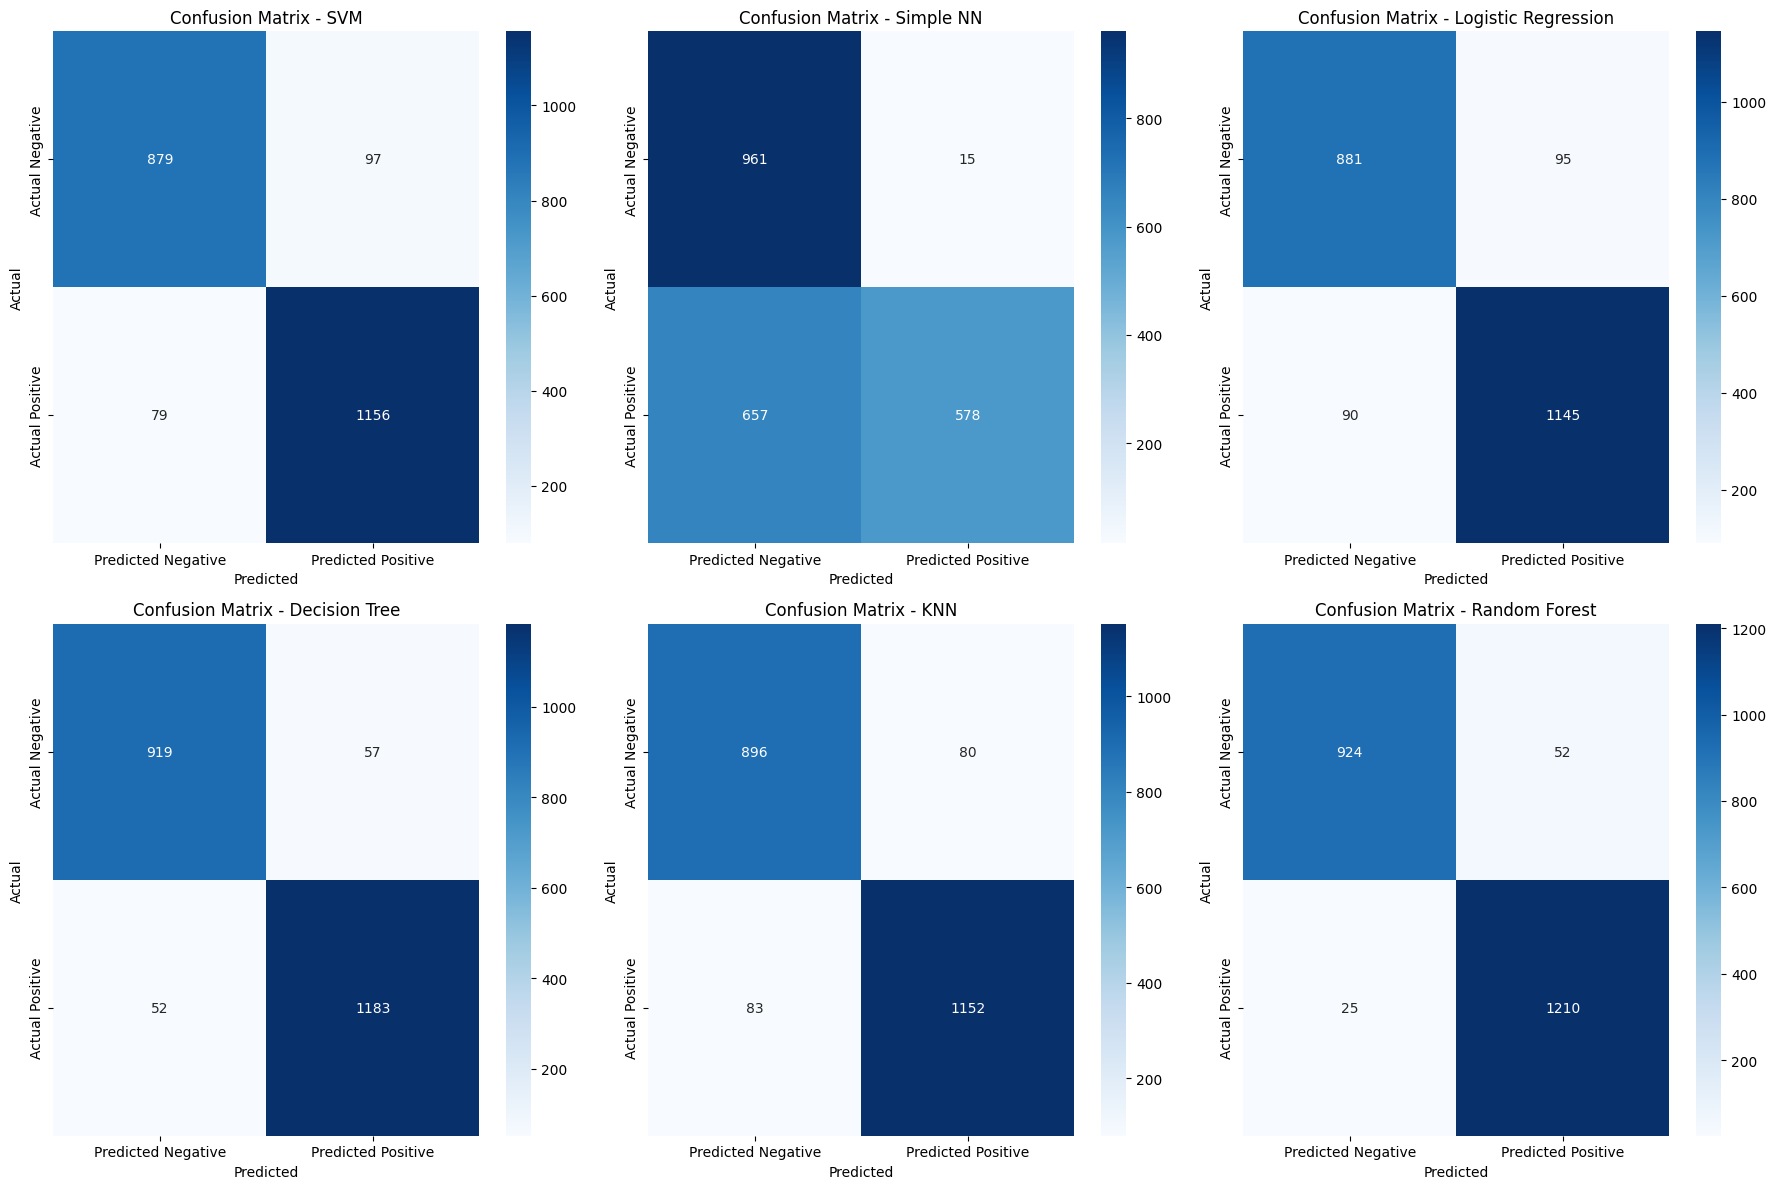

In [ ]:
# Confusion Matrix Comparison
models = ['SVM', 'Simple NN', 'Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']
y_preds = [y_pred_svm, y_pred_nn_binary, y_pred_lr, y_pred_dt, y_pred_knn, y_pred_rf] # Use binary predictions for NN

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (model_name, y_pred) in enumerate(zip(models, y_preds)):
    cm = confusion_matrix(y_val_nn_binary if model_name == 'Simple NN' else y_val, y_pred) # Use binary y_val for NN
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    axes[i].set_title(f'Confusion Matrix - {model_name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()

### ROC Curve Comparison

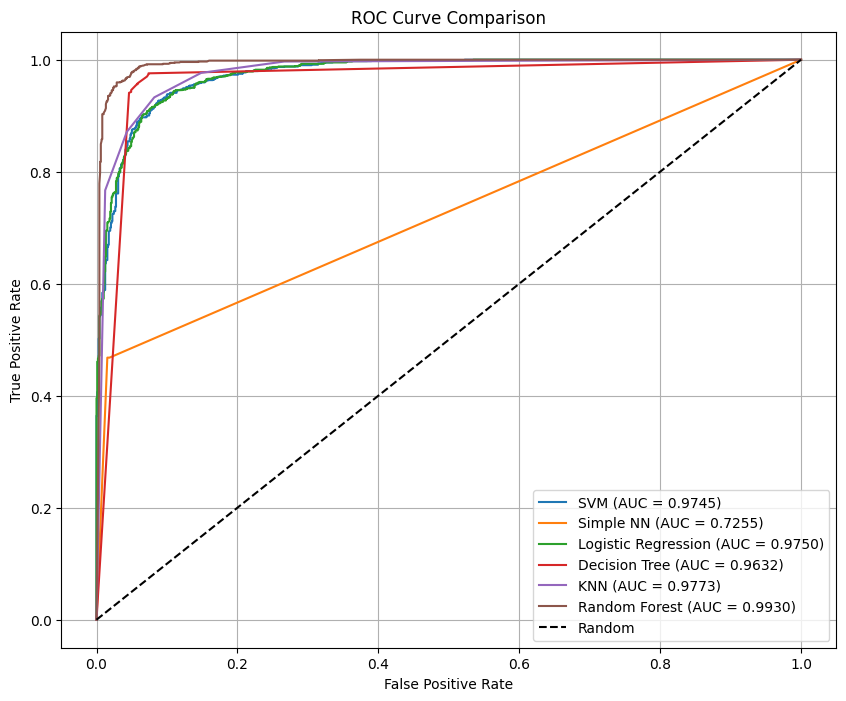

In [ ]:
# ROC Curve Comparison
# For models that output probabilities (like LR and NN), use predict_proba
# For models that don't directly output probabilities (like SVM, DT, KNN, RF with default settings),
# we can use decision_function for SVM and predict_proba for the others.
# Note: decision_function for binary SVM returns confidence scores, for others predict_proba returns probabilities.

models = ['SVM', 'Simple NN', 'Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest']
y_preds_proba = []

# SVM: Use decision_function
y_score_svm = svm_model.decision_function(X_val)
y_preds_proba.append(y_score_svm)

# Simple NN: Use predict_proba (already have y_pred_nn_prob)
y_preds_proba.append(y_pred_nn_prob.flatten())

# Logistic Regression: Use predict_proba
y_score_lr = lr_model.predict_proba(X_val)[:, 1]
y_preds_proba.append(y_score_lr)

# Decision Tree: Use predict_proba
y_score_dt = dt_model.predict_proba(X_val)[:, 1]
y_preds_proba.append(y_score_dt)

# KNN: Use predict_proba
y_score_knn = knn_model.predict_proba(X_val)[:, 1]
y_preds_proba.append(y_score_knn)

# Random Forest: Use predict_proba
y_score_rf = rf_model.predict_proba(X_val)[:, 1]
y_preds_proba.append(y_score_rf)


plt.figure(figsize=(10, 8))

# Use binary y_val for plotting ROC curves, as roc_curve expects 0/1 labels
y_val_binary_roc = y_val.values.flatten().copy()
y_val_binary_roc[y_val_binary_roc == -1] = 0

for i, (model_name, y_score) in enumerate(zip(models, y_preds_proba)):
    # For SVM and NN, the scores are not probabilities directly, but roc_curve handles this
    fpr, tpr, _ = roc_curve(y_val_binary_roc, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

# **Stacking Ensemble Application and Testing**

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time


# Define the base models (estimators)
# Using the trained models
estimators = [
    ('svm', svm_model),
    # ('nn', nn_model), # Removed the Keras model
    ('lr', lr_model),
    ('dt', dt_model),
    ('knn', knn_model),
    ('rf', rf_model)
]

# Define the meta-learner
meta_learner = LogisticRegression()

# Initialize the Stacking Classifier
stacking_model = StackingClassifier(estimators=estimators, final_estimator=meta_learner, cv=5) # Using 5-fold cross-validation

# Train the stacking model
# Note: StackingClassifier requires predictions from base models on out-of-fold data during training.
# It handles this internally using cross-validation.
# The target variable needs to be in the correct format for StackingClassifier (flattened)
y_train_flat = y_train.values.ravel()

start_train_time_stacking = time.time()
stacking_model.fit(X_train, y_train_flat)
train_time_stacking = time.time() - start_train_time_stacking


# Predict on the validation set
y_pred_stacking = stacking_model.predict(X_val)

# Evaluate the stacking model
accuracy_stacking = accuracy_score(y_val, y_pred_stacking)
precision_stacking = precision_score(y_val, y_pred_stacking)
recall_stacking = recall_score(y_val, y_pred_stacking)
f1_stacking = f1_score(y_val, y_pred_stacking)


print("Stacking Ensemble Model Evaluation:")
print(f"Accuracy: {accuracy_stacking:.4f}")
print(f"Precision: {precision_stacking:.4f}")
print(f"Recall: {recall_stacking:.4f}")
print(f"F1-Score: {f1_stacking:.4f}")
print(f"Training Time: {train_time_stacking:.4f} seconds")
print("-" * 30)

Stacking Ensemble Model Evaluation:
Accuracy: 0.9670
Precision: 0.9633
Recall: 0.9781
F1-Score: 0.9707
Training Time: 6.0270 seconds
------------------------------


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import time
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to calculate specificity and FNR
def calculate_additional_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    return specificity, fnr

# Predict on the test set using the stacking model and measure inference time
start_time = time.time()
y_pred_stacking_test = stacking_model.predict(X_test)
inference_time_stacking = time.time() - start_time

# Evaluate the stacking model on the test set
accuracy_stacking_test = accuracy_score(y_test, y_pred_stacking_test)
precision_stacking_test = precision_score(y_test, y_pred_stacking_test)
recall_stacking_test = recall_score(y_test, y_pred_stacking_test)
f1_stacking_test = f1_score(y_test, y_pred_stacking_test)
specificity_stacking_test, fnr_stacking_test = calculate_additional_metrics(y_test, y_pred_stacking_test)


print("Stacking Ensemble Model Evaluation on Test Set:")
print(f"Accuracy: {accuracy_stacking_test:.4f}")
print(f"Precision: {precision_stacking_test:.4f}")
print(f"Recall: {recall_stacking_test:.4f}")
print(f"F1-Score: {f1_stacking_test:.4f}")
print(f"Specificity: {specificity_stacking_test:.4f}")
print(f"FNR: {fnr_stacking_test:.4f}")
print(f"Inference Time: {inference_time_stacking:.4f} seconds")
# print(f"Training Time: {train_time_stacking:.4f} seconds") # Training time is printed in the training cell
print("-" * 30)

Stacking Ensemble Model Evaluation on Test Set:
Accuracy: 0.9701
Precision: 0.9706
Recall: 0.9781
F1-Score: 0.9743
Specificity: 0.9591
FNR: 0.0219
Inference Time: 0.3430 seconds
------------------------------


# **Stacking Ensemble Model Evaluation**

### Stacking Ensemble Confusion Matrix on Test Set

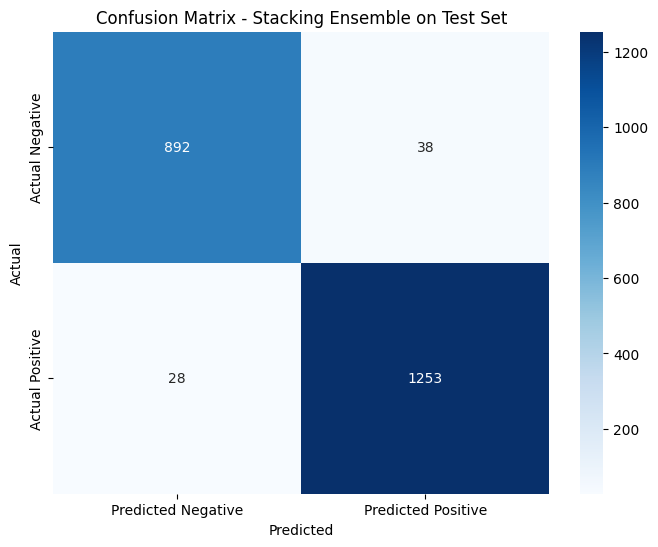

In [ ]:
# Confusion Matrix for Stacking Ensemble on Test Set
cm_stacking = confusion_matrix(y_test, y_pred_stacking_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_stacking, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix - Stacking Ensemble on Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Stacking Ensemble ROC Curve on Test Set

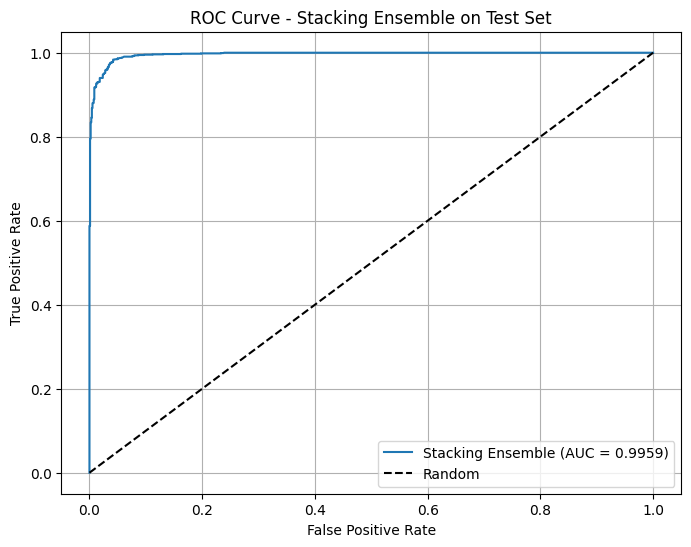

In [ ]:
# ROC Curve for Stacking Ensemble on Test Set
# StackingClassifier does not have predict_proba directly on the final estimator level after fitting.
# However, we can get the probabilities from the final estimator after prediction on the test set.
# Alternatively, we can use decision_function if available and appropriate for the meta-learner.
# For Logistic Regression meta-learner, predict_proba is suitable.

# Get probabilities for the positive class from the stacking model
# Note: This will use the meta-learner to predict probabilities based on the predictions of the base models.
# It's not the same as getting probabilities from individual base models.
y_score_stacking_test = stacking_model.predict_proba(X_test)[:, 1]

# Use binary y_test for plotting ROC curves, as roc_curve expects 0/1 labels
y_test_binary_roc = y_test.values.flatten().copy()
y_test_binary_roc[y_test_binary_roc == -1] = 0


fpr_stacking, tpr_stacking, _ = roc_curve(y_test_binary_roc, y_score_stacking_test)
roc_auc_stacking = auc(fpr_stacking, tpr_stacking)

plt.figure(figsize=(8, 6))
plt.plot(fpr_stacking, tpr_stacking, label=f'Stacking Ensemble (AUC = {roc_auc_stacking:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Stacking Ensemble on Test Set')
plt.legend()
plt.grid(True)
plt.show()